In [13]:
!pip install "numpy<2"

import numpy as np
from sklearn.decomposition import FastICA as skFastICA
import matplotlib.pyplot as plt
import time
import pandas as pd
# !pip install mne
import mne
from mne.datasets import sample
from sklearn.decomposition import FastICA

# Partie 1


## OUTILS ET METRIQUES

In [46]:
def amari_index(V, W_true):
    """
    Calcule l'indice d'Amari (Amari et al., 1996).
    Metrique de reference pour evaluer la qualite de separation.
    Proche de 0 = Separation parfaite.
    """
    D = V.shape[0]
    C = V @ W_true
    abs_C = np.abs(C)

    # Normalisation par les maxima de lignes et colonnes
    row_sums = np.sum(abs_C / np.max(abs_C, axis=1, keepdims=True), axis=1) - 1
    col_sums = np.sum(abs_C / np.max(abs_C, axis=0, keepdims=True), axis=0) - 1

    return (np.sum(row_sums) + np.sum(col_sums)) / (2 * D * (D - 1))

# 1. Blanchiment avec Réduction de Dimension (PCA intégrée)
def whitening(X, n_components=None, epsilon=1e-5):
    """
    Blanchiment avec Réduction de Dimension (PCA intégrée).
    Essentiel pour répondre à la thématique 'Réduction de Dimension'.
    """
    X_centered = X - np.mean(X, axis=0)
    cov = np.cov(X_centered.T)
    d, E = np.linalg.eigh(cov)

    # Tri décroissant des valeurs propres
    idx = np.argsort(d)[::-1]
    d, E = d[idx], E[:, idx]

    # Réduction de dimension (Optionnel)
    if n_components is not None:
        d, E = d[:n_components], E[:, :n_components]

    # Matrice de blanchiment (W_white = E * D^-1/2)
    D_inv = np.diag(1.0 / np.sqrt(d + epsilon))
    W_white = E @ D_inv

    X_white = X_centered @ W_white
    return X_white, W_white

def score_func(y, source_type='super'):
    """
    Fonction score g(y) adaptée à la statistique des sources.
    'super' : sources à queues lourdes (tanh). Adaptee aux sources super-gaussiennes (Loi de Laplace, etc.).
              tanh(y) est l'estimateur du maximum de vraisemblance pour des sources super-gaussiennes (kurtosis > 0).
    'sub'   : sources à queues légères (y^3)
    """
    if source_type == 'super':
        return np.tanh(y)
    else:
        return y**3

## ALGORITHMES (LES 3 VARIANTES)

In [47]:
def run_fastica_baseline(Xw, n_components=None):
    """
    ALGO 1 : FastICA (Hyvärinen, 1999).
    Reference deterministe via scikit-learn.
    """
    import warnings
    # On enlève n_components car Xw est déjà réduit par notre propre fonction whitening
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        transformer = FastICA(whiten=False, random_state=42)
        transformer.fit(Xw)
    return transformer.components_

import time
import numpy as np
from scipy.linalg import sqrtm

def run_sgd_ica(Xw, W_true=None, W_white=None, lr=0.001, epochs=5):
    """
    ALGO 2 : SGD-ICA (Infomax stochastique).
    Mise à jour classique basée sur la log-vraisemblance.
    """
    D = Xw.shape[1]
    N = len(Xw)
    
    # Initialisation orthogonale
    q, _ = np.linalg.qr(np.random.randn(D, D))
    V = q
    history = []

    start_time = time.time()
    for epoch in range(epochs):
        # Décroissance du learning rate
        current_lr = lr / (1 + epoch)
        idx = np.random.permutation(N)
        
        # --- MISE À JOUR STOCHASTIQUE (Échantillon par échantillon) ---
        for i in idx:
            x_i = Xw[i:i+1].T  # Dimension (D, 1)
            y = V @ x_i

            try:
                grad = np.linalg.inv(V.T + 1e-6 * np.eye(D)) - score_func(y) @ x_i.T
                V += current_lr * grad
            except np.linalg.LinAlgError:
                continue
                
        # On force V à rester orthogonale après avoir vu tous les échantillons de l'époque.
        # V <- (V * V^T)^{-1/2} * V
        V = np.linalg.inv(sqrtm(V @ V.T)).real @ V

        # --- ÉVALUATION ---
        # Calcul d'Amari global à la fin de chaque époque
        if W_true is not None and W_white is not None:
            V_global = V @ W_white.T
            history.append(amari_index(V_global, W_true))

    return V, history, time.time() - start_time

def run_natural_gradient_ica(Xw, W_true=None, W_white=None, lr=0.01, epochs=10, batch_size=1, source_type='super'):
    """
    ALGO 3 : Natural Gradient SGD (Amari, 1998).
    Exploite la geometrie de l'information pour accelerer la convergence.
    batch_size > 1 permet de réduire la variance du gradient pour la causalité.
    # La mise à jour (I - g(y)y.T)V est équivariante : la performance est indépendante du conditionnement de W.
    """
    D = Xw.shape[1]
    N = len(Xw)
    q, _ = np.linalg.qr(np.random.randn(D, D))
    V = q
    history = []

    start_time = time.time()
    for epoch in range(epochs):
        current_lr = lr / (1 + epoch * 0.5)
        idx = np.random.permutation(N)

        for i in range(0, N, batch_size):
            sel = idx[i:i + batch_size]
            x_batch = Xw[sel].T
            m = len(sel)

            y = V @ x_batch

            # Mise à jour équivariante (pas d'inversion matricielle)
            phi_y_yT = (score_func(y, source_type) @ y.T) / m
            update = (np.eye(D) - phi_y_yT) @ V
            V += current_lr * update

            if W_true is not None and i % 200 == 0:
                V_global = V @ W_white.T
                history.append(amari_index(V_global, W_true))

    return V, history, time.time() - start_time

# # Le réordonnancement aléatoire à chaque époque est crucial pour éviter les cycles limites en optimisation stochastique.

## BENCHMARK ET VALIDATION

Lancement du benchmark (10 runs)...

      RÉSULTATS NUMÉRIQUES FINAUX
 Algorithme  Amari Moyen (mu)  Amari Ecart-type (sigma)  Temps moyen (s)
    FastICA            0.0220                    0.0059           0.0014
        SGD            0.3449                    0.1420           0.6245
NaturalGrad            0.0212                    0.0067           0.2062


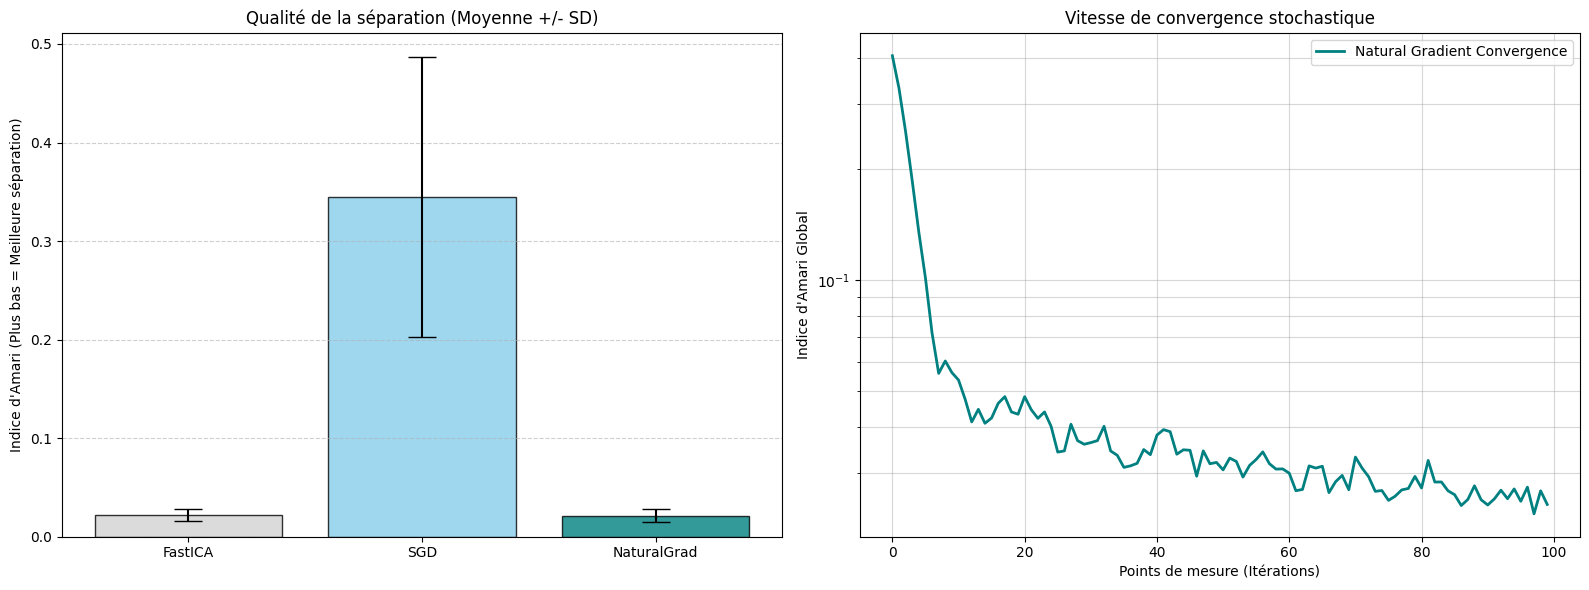

In [48]:
def execute_benchmark(n_runs=10):
    """
    Évalue la qualité (Amari), la stabilité (Écart-type) et la vitesse (Temps).
    Affiche un tableau récapitulatif et des graphiques de convergence.
    """
    # Initialisation des dictionnaires pour stocker les scores et les temps
    results = {'FastICA': [], 'SGD': [], 'NaturalGrad': []}
    times = {'FastICA': [], 'SGD': [], 'NaturalGrad': []}

    # Pour tracer une courbe de convergence moyenne (Natural Gradient)
    hist_ng_total = []

    D = 3  # Nombre de sources
    print(f"Lancement du benchmark ({n_runs} runs)...")

    for run in range(n_runs):
        np.random.seed(run)

        # 1. Génération de données synthétiques
        S = np.random.laplace(size=(2000, D))
        W_true = np.random.randn(D, D)
        X = S @ W_true.T

        # 2. Blanchiment 
        Xw, W_white = whitening(X, n_components=D)

        # --- ALGO 1 : FastICA (Baseline) ---
        t0 = time.time()
        V_fi = run_fastica_baseline(Xw, D)
        times['FastICA'].append(time.time() - t0)
        # Amari global : on évalue la chaîne complète (Blanchiment + ICA)
        results['FastICA'].append(amari_index(V_fi @ W_white.T, W_true))

        # --- ALGO 2 : SGD-ICA (Infomax) ---
        V_sgd, hist_sgd, duration_sgd = run_sgd_ica(Xw, W_true=W_true, W_white=W_white, epochs=10)
        results['SGD'].append(amari_index(V_sgd @ W_white.T, W_true))
        times['SGD'].append(duration_sgd)

        # --- ALGO 3 : Natural Gradient ---
        V_ng, hist_ng, duration_ng = run_natural_gradient_ica(Xw, W_true=W_true, W_white=W_white, epochs=10)
        results['NaturalGrad'].append(amari_index(V_ng @ W_white.T, W_true))
        times['NaturalGrad'].append(duration_ng)
        hist_ng_total.append(hist_ng)

    # --- CALCUL DES STATISTIQUES FINALES ---
    methods = list(results.keys())
    means_amari = [np.mean(results[m]) for m in methods]
    stds_amari = [np.std(results[m]) for m in methods]
    means_time = [np.mean(times[m]) for m in methods]

    # --- AFFICHAGE DU TABLEAU DE RÉSULTATS  ---
    df_results = pd.DataFrame({
        'Algorithme': methods,
        'Amari Moyen (mu)': np.round(means_amari, 4),
        'Amari Ecart-type (sigma)': np.round(stds_amari, 4),
        'Temps moyen (s)': np.round(means_time, 4)
    })

    print("\n" + "="*40)
    print("      RÉSULTATS NUMÉRIQUES FINAUX")
    print("="*40)
    print(df_results.to_string(index=False))
    print("="*40)

    # --- GÉNÉRATION DES GRAPHIQUES ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # 1. Barplot de l'indice d'Amari (Précision)
    ax1.bar(methods, means_amari, yerr=stds_amari, capsize=10,
            color=['lightgrey', 'skyblue', 'teal'], edgecolor='black', alpha=0.8)
    ax1.set_ylabel("Indice d'Amari (Plus bas = Meilleure séparation)")
    ax1.set_title('Qualité de la séparation (Moyenne +/- SD)')
    ax1.grid(axis='y', linestyle='--', alpha=0.6)

    # 2. Courbe de convergence (Dynamique)
    # On fait la moyenne des historiques de convergence sur tous les runs
    avg_hist_ng = np.mean(hist_ng_total, axis=0)
    ax2.plot(avg_hist_ng, color='teal', lw=2, label='Natural Gradient Convergence')
    ax2.set_yscale('log') # Log-scale pour voir la stabilisation fine
    ax2.set_xlabel("Points de mesure (Itérations)")
    ax2.set_ylabel("Indice d'Amari Global")
    ax2.set_title('Vitesse de convergence stochastique')
    ax2.legend()
    ax2.grid(True, which="both", ls="-", alpha=0.5)

    plt.tight_layout()
    plt.show()

    return df_results

# Pour lancer le tout :
if __name__ == "__main__":
    df_final = execute_benchmark(n_runs=10)

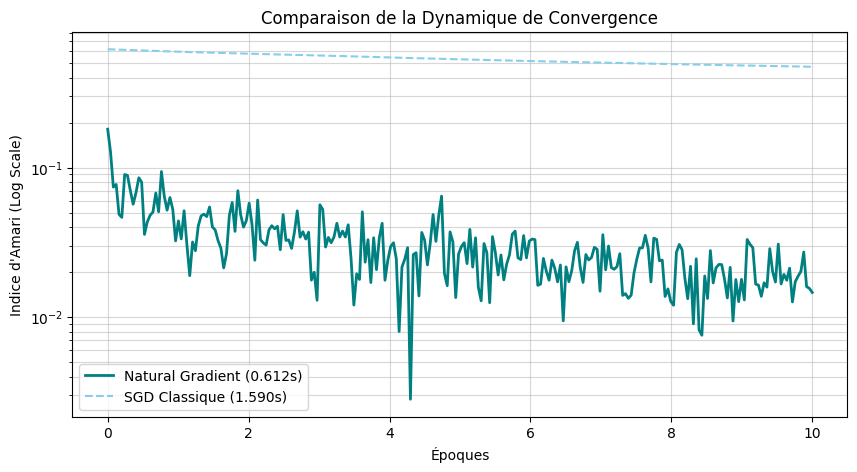

In [49]:
def compare_complexity_and_convergence():
    # Génération de données (Sources non-gaussiennes)
    S = np.random.laplace(size=(5000, 3))
    W_true = np.random.randn(3, 3)

    Xw, W_white = whitening(S @ W_true.T)

    # 1. Test Natural Gradient (Amari, 1998)
    # 10 époques
    V_ng, hist_ng, time_ng = run_natural_gradient_ica(Xw, W_true=W_true, W_white=W_white, lr=0.01, epochs=10)

    # 2. Test SGD Classique (Infomax)
    # 10 époques
    V_sgd, hist_sgd, time_sgd = run_sgd_ica(Xw, W_true=W_true, W_white=W_white, lr=0.001, epochs=10)

    # On crée des abscisses normalisées de 0 à 10 époques pour les deux courbes.
    # Ainsi, peu importe le nombre de points dans 'hist', les courbes finiront toutes les deux à x=10.
    x_ng = np.linspace(0, 10, len(hist_ng))
    x_sgd = np.linspace(0, 10, len(hist_sgd))

    # Visualisation
    plt.figure(figsize=(10, 5))
    
    # On ajoute x_ng et x_sgd dans les plot()
    plt.plot(x_ng, hist_ng, label=f"Natural Gradient ({time_ng:.3f}s)", color='teal', lw=2)
    plt.plot(x_sgd, hist_sgd, label=f"SGD Classique ({time_sgd:.3f}s)", color='skyblue', linestyle='--')

    plt.yscale('log') # Échelle logarithmique pour observer la stabilisation
    plt.title("Comparaison de la Dynamique de Convergence")
    plt.xlabel("Époques") # On précise que l'axe X représente désormais les époques
    plt.ylabel("Indice d'Amari (Log Scale)")
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.show()

compare_complexity_and_convergence()

## Données réelles


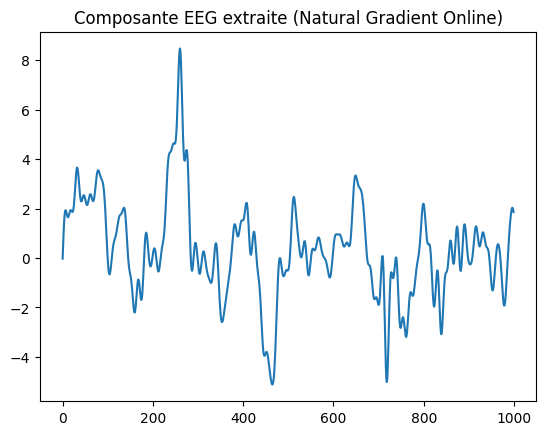

In [50]:
# 1. Charger un dataset réel
data_path = sample.data_path()
raw_fname = data_path / 'MEG' / 'sample' / 'sample_audvis_raw.fif'
raw = mne.io.read_raw_fif(raw_fname, preload=True, verbose=False)

# 2. Nettoyage
raw.filter(1, 40, verbose=False)
data = raw.get_data(picks='eeg', start=0, stop=10000).T

# 3. Application ICA (Modifié pour gérer W_white)
Xw_eeg, W_white_eeg = whitening(data, n_components=5) # On réduit à 5 composantes

# On lance sans W_true car on ne connaît pas la vérité terrain sur l'EEG
V_eeg, _, _ = run_natural_gradient_ica(Xw_eeg, lr=0.01, epochs=10, batch_size=1)
S_eeg = Xw_eeg @ V_eeg.T

# Visualisation
plt.plot(S_eeg[:1000, 0])
plt.title("Composante EEG extraite (Natural Gradient Online)")
plt.show()


ÉVALUATION STATISTIQUE (DONNÉES RÉELLES)
 Algorithme  Kurtosis Moyen  Erreur Décorrélation
    FastICA          6.0385                0.5597
        SGD          7.8394                0.7075
NaturalGrad          3.7980                0.0227


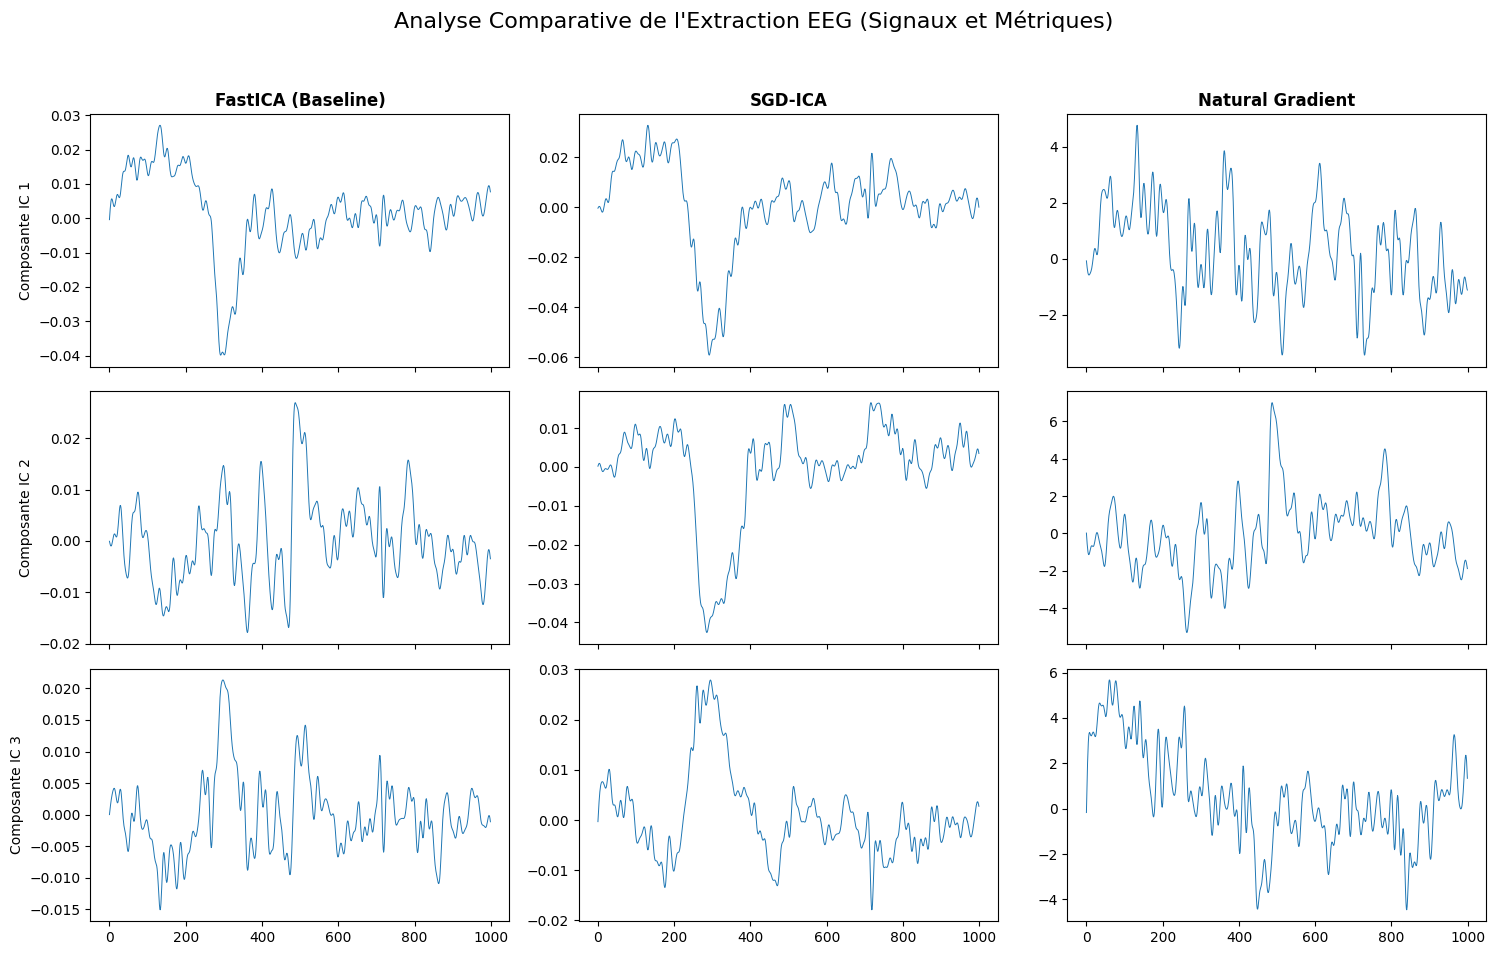

In [51]:
from scipy.stats import kurtosis
import pandas as pd

def benchmark_real_eeg_complet():
    """
    Évaluation complète sur données réelles (MNE).
    Sortie : Tableau de bord statistique + Grille de visualisation.
    """
    # 1. Chargement et Préparation des données réelles
    data_path = sample.data_path()
    raw = mne.io.read_raw_fif(data_path / 'MEG' / 'sample' / 'sample_audvis_raw.fif', preload=True, verbose=False)

    # Nettoyage : filtre passe-bande $1-40$ Hz
    raw.filter(1, 40, verbose=False)
    data = raw.get_data(picks='eeg', start=0, stop=5000).T

    # Blanchiment avec réduction de dimension à $n=5$ composantes
    Xw, W_white = whitening(data, n_components=5)

    # 2. Exécution des algorithmes 
    # FastICA (Baseline de référence) 
    V_fi = run_fastica_baseline(Xw, n_components=Xw.shape[1])
    S_fi = Xw @ V_fi.T

    # SGD-ICA (Online classique) 
    V_sgd, _, _ = run_sgd_ica(Xw, lr=1e-4, epochs=20)
    S_sgd = Xw @ V_sgd.T

    # Natural Gradient (Variante avancée Amari) 
    V_ng, _, _ = run_natural_gradient_ica(Xw, lr=1e-3, epochs=20, batch_size=1)
    S_ng = Xw @ V_ng.T

    # 3. ÉVALUATION NUMÉRIQUE 
    methods_dict = {'FastICA': S_fi, 'SGD': S_sgd, 'NaturalGrad': S_ng}
    stats_real = []

    for name, S in methods_dict.items():
        # Kurtosis : Mesure la non-gaussianité (plus il est élevé, mieux c'est) 
        kurt_val = np.mean(np.abs(kurtosis(S, axis=0)))
        # Erreur de décorrélation : Mesure l'indépendance résiduelle
        corr_S = np.corrcoef(S.T)
        decorr_err = np.sum(np.abs(corr_S - np.eye(5))) / (5 * 4)

        stats_real.append({
            'Algorithme': name,
            'Kurtosis Moyen': round(kurt_val, 4),
            'Erreur Décorrélation': round(decorr_err, 4)
        })

    df_real = pd.DataFrame(stats_real)
    print("\n" + "="*45)
    print("ÉVALUATION STATISTIQUE (DONNÉES RÉELLES)")
    print("="*45)
    print(df_real.to_string(index=False))
    print("="*45)

    # 4. VISUALISATION GRAPHIQUE
    fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharex=True)
    methods_data = [S_fi, S_sgd, S_ng]
    titles = ["FastICA (Baseline)", "SGD-ICA", "Natural Gradient"]

    for col in range(3):
        for row in range(3):
            # Affichage des 1000 premiers points pour la clarté
            axes[row, col].plot(methods_data[col][:1000, row], lw=0.7)
            if row == 0:
                axes[row, col].set_title(titles[col], fontweight='bold')
            if col == 0:
                axes[row, col].set_ylabel(f"Composante IC {row+1}")

    plt.suptitle("Analyse Comparative de l'Extraction EEG (Signaux et Métriques)", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    return df_real

if __name__ == "__main__":
    benchmark_real_eeg_complet()

# Partie 2


Exécution FastICA (Baseline)...
Exécution Natural Gradient (Stochastique)...

   ÉVALUATION NUMÉRIQUE DE L'INFÉRENCE CAUSALE (LinGAM)
Métrique / Lien Causal Vérité Terrain FastICA (Baseline) Natural Gradient
         Lien X0 -> X1          0.800              0.821            0.872
         Lien X0 -> X2          0.500              0.482            0.988
         Lien X1 -> X2         -0.700             -0.683           -0.788
         Lien X2 -> X3          0.600              0.579            0.000
   -------------------            ---                ---              ---
  Erreur Globale (MAE)          0.000              0.005            0.323



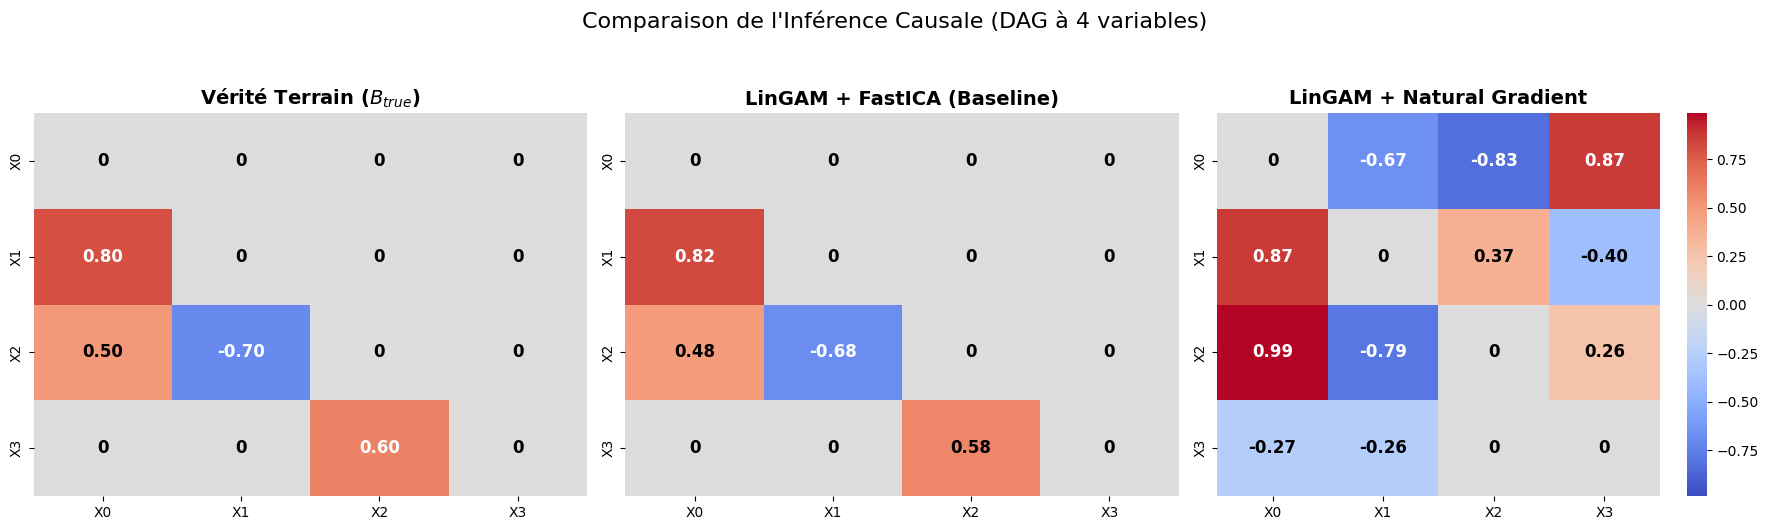

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import linear_sum_assignment

def run_lingam_discovery(X, algo='natural_gradient', **kwargs):
    """
    CONTRIBUTION CRÉATIVE : Inférence causale avec LinGAM.
    Découvre la matrice de causalité B dans le modèle x = Bx + e.
    """
    n_features = X.shape[1]

    # 1. Blanchiment
    Xw, W_white = whitening(X)

    # 2. Estimation ICA
    if algo == 'fastica':
        V_est = run_fastica_baseline(Xw, n_components=n_features)
    elif algo == 'natural_gradient':
        epochs = kwargs.get('epochs', 200) 
        batch_size = kwargs.get('batch_size', 64)
        lr = kwargs.get('lr', 0.01)
        V_est, _, _ = run_natural_gradient_ica(Xw, epochs=epochs, batch_size=batch_size, lr=lr)
    else:
        raise ValueError("Algo non reconnu.")

    # 3. Matrice de démélange totale
    W_total = V_est @ W_white.T

    # 4. Ambiguïté de Permutation ET D'ÉCHELLE
    row_max = np.max(np.abs(W_total), axis=1, keepdims=True)
    row_max[row_max == 0] = 1e-9 
    cost_matrix = -(np.abs(W_total) / row_max) 
    
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    
    # Réarrangement des lignes
    sort_indices = np.argsort(col_ind)
    W_total = W_total[row_ind[sort_indices]]

    # 5. Normalisation et extraction de B
    diag_W = np.diag(W_total).copy()[:, None] 
    diag_W[diag_W == 0] = 1e-9 
    
    W_norm = W_total / diag_W
    B_est = np.eye(n_features) - W_norm

    # 6. Seuillage (Sparsity)
    B_est[np.abs(B_est) < 0.2] = 0

    return B_est


def test_and_plot_lingam_complex():
    np.random.seed(42)
    n_points = 3000

    # Génération du graphe causal (DAG)
    e = np.random.laplace(size=(4, n_points))
    
    x0 = e[0]
    x1 = 0.8 * x0 + e[1]
    x2 = 0.5 * x0 - 0.7 * x1 + e[2]
    x3 = 0.6 * x2 + e[3]
    X_causal = np.c_[x0, x1, x2, x3]

    B_true = np.array([
        [0.0, 0.0, 0.0, 0.0],
        [0.8, 0.0, 0.0, 0.0],
        [0.5,-0.7, 0.0, 0.0],
        [0.0, 0.0, 0.6, 0.0]
    ])

    print("Exécution FastICA (Baseline)...")
    B_fastica = run_lingam_discovery(X_causal, algo='fastica')

    print("Exécution Natural Gradient (Stochastique)...")
    B_ng = run_lingam_discovery(X_causal, algo='natural_gradient', epochs=200, batch_size=64)

    # ==========================================================
    # --- TABLEAU RÉCAPITULATIF DES PERFORMANCES ---
    # ==========================================================
    mae_fastica = np.mean(np.abs(B_fastica - B_true))
    mae_ng = np.mean(np.abs(B_ng - B_true))

    metrics = {
        "Métrique / Lien Causal": [
            "Lien X0 -> X1", 
            "Lien X0 -> X2", 
            "Lien X1 -> X2", 
            "Lien X2 -> X3", 
            "-------------------",
            "Erreur Globale (MAE)"
        ],
        "Vérité Terrain": [0.8, 0.5, -0.7, 0.6, "---", 0.0],
        "FastICA (Baseline)": [
            B_fastica[1,0], B_fastica[2,0], B_fastica[2,1], B_fastica[3,2], "---", mae_fastica
        ],
        "Natural Gradient": [
            B_ng[1,0], B_ng[2,0], B_ng[2,1], B_ng[3,2], "---", mae_ng
        ]
    }

    df_metrics = pd.DataFrame(metrics)
    
    print("\n" + "="*70)
    print("   ÉVALUATION NUMÉRIQUE DE L'INFÉRENCE CAUSALE (LinGAM)")
    print("="*70)
    # Affichage formaté à 3 décimales pour les chiffres
    print(df_metrics.to_string(index=False, float_format=lambda x: f"{x:.3f}" if isinstance(x, float) else x))
    print("="*70 + "\n")


   # --- AFFICHAGE COMPARATIF (HEATMAPS) ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    labels = ['X0', 'X1', 'X2', 'X3']
    cmap = 'coolwarm'
    vmax = max(np.max(np.abs(B_true)), np.max(np.abs(B_fastica)), np.max(np.abs(B_ng)))

    # Heatmap 1 : Vérité Terrain 
    sns.heatmap(B_true, annot=False, cmap=cmap, center=0, vmin=-vmax, vmax=vmax,
                xticklabels=labels, yticklabels=labels, ax=axes[0], cbar=False)
    axes[0].set_title("Vérité Terrain ($B_{true}$)", fontsize=14, fontweight='bold')
    
    # Heatmap 2 : FastICA
    sns.heatmap(B_fastica, annot=False, cmap=cmap, center=0, vmin=-vmax, vmax=vmax,
                xticklabels=labels, yticklabels=labels, ax=axes[1], cbar=False)
    axes[1].set_title("LinGAM + FastICA (Baseline)", fontsize=14, fontweight='bold')
    
    # Heatmap 3 : Natural Gradient 
    sns.heatmap(B_ng, annot=False, cmap=cmap, center=0, vmin=-vmax, vmax=vmax,
                xticklabels=labels, yticklabels=labels, ax=axes[2])
    axes[2].set_title("LinGAM + Natural Gradient", fontsize=14, fontweight='bold')

    matrices = [B_true, B_fastica, B_ng]
    for idx, ax in enumerate(axes):
        mat = matrices[idx]
        for i in range(4):
            for j in range(4):
                val = mat[i, j]
                # On écrit le texte au centre de chaque case (j+0.5, i+0.5)
                # Si la valeur est 0, on écrit "0", sinon on formate à 2 décimales
                text = "0" if val == 0 else f"{val:.2f}"
                # Couleur du texte : blanc si la case est très foncée, noir sinon
                text_color = "white" if abs(val) > (vmax * 0.6) else "black"
                
                ax.text(j + 0.5, i + 0.5, text,
                        ha="center", va="center", color=text_color,
                        fontsize=12, fontweight="bold")

    plt.suptitle("Comparaison de l'Inférence Causale (DAG à 4 variables)", fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()

# --- LANCEMENT ---
if __name__ == "__main__":
    test_and_plot_lingam_complex()